In [1]:
import numpy as np
import os

from glob import glob

from keras.src.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing.text import text_to_word_sequence
## 라벨인코더-> 카테고리형 문자를 숫자로 자동 변환해주는 역할
from sklearn.preprocessing import LabelEncoder

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## 딥러닝 모델을 만들자!!!!!!!
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import os
from tensorflow.keras.preprocessing import *

C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import os
print(os.getcwd())

C:\Users\Administrator\Documents\deep\deep01


In [3]:
from pathlib import Path
base = Path("img-animal") # 현재 폴더 경로

cat_files = sorted((base/"cat").glob("*.jpg"))
cat_files[:3]
dog_files = sorted((base/"dog").glob("*.jpg"))
dog_files[:3]

[WindowsPath('img-animal/dog/dog.0.jpg'),
 WindowsPath('img-animal/dog/dog.1.jpg'),
 WindowsPath('img-animal/dog/dog.10.jpg')]

In [4]:
data_files = cat_files + dog_files #리스트
data_files[0], len(data_files)

(WindowsPath('img-animal/cat/cat.0.jpg'), 4000)

In [5]:
img0 = cv2.imread(data_files[0])
img0

array([[[ 87, 164, 203],
        [ 87, 164, 203],
        [ 88, 165, 204],
        ...,
        [122, 201, 240],
        [121, 200, 239],
        [120, 199, 238]],

       [[ 87, 164, 203],
        [ 87, 164, 203],
        [ 88, 165, 204],
        ...,
        [123, 202, 241],
        [122, 201, 240],
        [120, 199, 238]],

       [[ 87, 164, 203],
        [ 87, 164, 203],
        [ 88, 165, 204],
        ...,
        [123, 202, 241],
        [122, 201, 240],
        [121, 200, 239]],

       ...,

       [[ 55, 122, 153],
        [ 55, 122, 153],
        [ 55, 122, 153],
        ...,
        [  0,   2,   2],
        [  0,   2,   2],
        [  0,   2,   2]],

       [[ 54, 121, 152],
        [ 54, 121, 152],
        [ 54, 121, 152],
        ...,
        [  0,   2,   2],
        [  0,   2,   2],
        [  0,   2,   2]],

       [[ 53, 120, 151],
        [ 53, 120, 151],
        [ 53, 120, 151],
        ...,
        [  0,   1,   1],
        [  0,   1,   1],
        [  0,   1,   1]]

In [6]:
img0.shape #가로 374픽셀, 세로 500픽셀, 3이면 BGR(칼라가 있음.)

(374, 500, 3)

In [7]:
# img00 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)

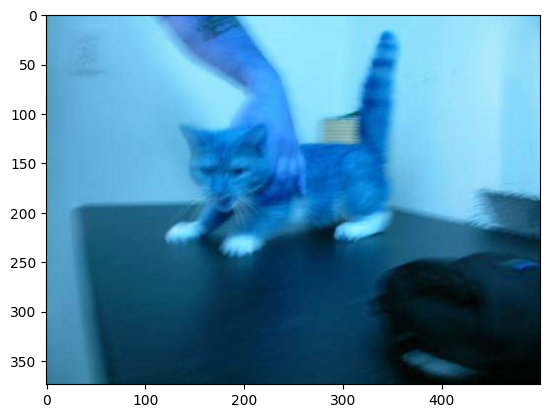

In [8]:
plt.imshow(img0)

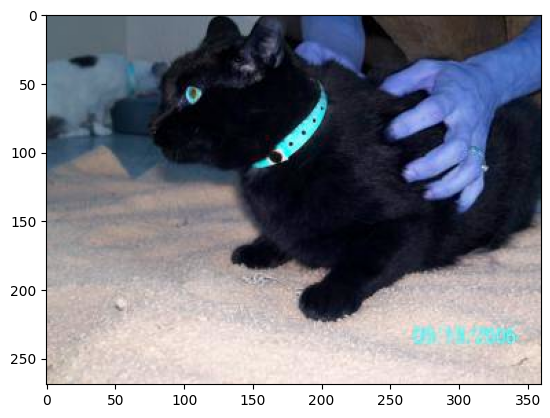

In [9]:
img1 = cv2.imread(data_files[100])
# img11 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
plt.imshow(img1)

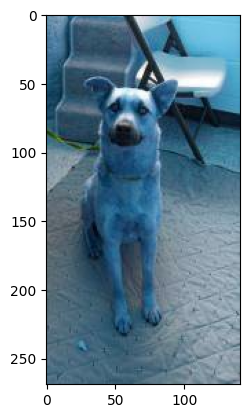

In [10]:
plt.imshow(cv2.imread(data_files[3000]))

In [23]:
def make_file(data_height, data_width, channel_n, data_list_n):
    # 각 이미지마다 라벨링 필요
    # 각 이미지를 읽어서 해당폴더명을 추출한다음에 해당폴더명이 cat(0), dog(1)
    label = []

    ## 텐서플로우 사이트에서 제공하는 모델사용하려고 함.
    ## 이미지를 4차원으로 만들어서 넣어주면 됨.
    ## 이미지 스케일링 작업을 한 후 4차원을 만들어 넣어줄 4차원 빈 리스트를 만들어 두자.
    images = np.zeros((data_list_n, data_height, data_width, channel_n))
    # print(images.shape) # (4000, 150, 150, 3)

    for i, image in enumerate(data_files):
        # print(i, image)
        # print(type(image)) # <class 'pathlib.WindowsPath'>
        folder = str(image).split("\\")[1] #['img-animal', 'cat', 'cat.0.jpg']
        # print(folder)
        result = 0 # cat이면 0번으로 설정
        if folder == 'dog':
            result = 1
        label.append(result)
        # if i % 10 == 0:
        #     print(i, image, "last_label=", result)
        #     print("label: ", label)
        #     print("-----------------------------")

        # 이미지는 255로 나누어 계산할 숫자크기를 줄여서 스케일링을 해주는 편임.
        # 1. 이미지를 읽자.
        image2 = cv2.imread(image)
        # 2. 같은 사이즈로 맞추어 주자 가로 150, 세로 150
        # 3. 255로 나누어 스케일링을 하자.
        image3 = cv2.resize(image2, (data_height, data_width)) / 255
        #print(image3)
        # 3차원 데이터를 앞에 i붙여서 4차원으로 만들어줌.
        images[i, :, :, :] = image3

    return np.array(label), images

In [24]:
labels, images = make_file(150, 150, 3, 4000)

In [25]:
X = images
y = labels

In [26]:
labels[:10], labels[-11 : -1]

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

In [28]:
np.unique(labels)

array([0, 1])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size= 0.2,
                                                    random_state=55,
                                                    shuffle=True
                                                   )
print(X_train.shape, X_test.shape)

(3200, 150, 150, 3) (800, 150, 150, 3)


In [30]:
# 모델 설정
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
# 옵티마이저, 손실함수 설정

In [31]:
cnn_base = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(150, 150, 3)
)
cnn_base.trainable = False
# 역전파를 해도 가중치가 업데이트되지 않음

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

In [33]:
model = Sequential()
model.add(tf.keras.Input(shape=(150, 150, 3)))
model.add(cnn_base)
# 이 줄이 핵심: 그냥 GlobalAveragePooling2D() 호출이 아니라 add로 넣어야 함
model.add(GlobalAveragePooling2D())
model.add(Dense(1, activation="sigmoid"))

In [34]:
# 옵티마이저, 손실함수 설정
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy']
             )

In [35]:
# 훈련시키자
# 콜백함수 --> 조기종료, 가장 성능이 좋을 때를 체크해서 모델에 대한 정보+가중치를 저장(체크포인트)
es = EarlyStopping(patience=3, restore_best_weights=True)
cp = ModelCheckpoint('best_cnn_final.h5')

In [ ]:
cnn_history = model.fit(
                X_train,
                y_train,
                batch_size=128,
                epochs=10,
                validation_data= (X_test, y_test),
                callbacks=[es, cp],
                verbose=2
)

Epoch 1/10


25/25 - 91s - 4s/step - accuracy: 0.6122 - loss: 0.6644 - val_accuracy: 0.6363 - val_loss: 0.6592
Epoch 2/10


In [ ]:
test_result = model.evaluate(X_test,y_test)
test_result

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1) ## 1행2열의 도표, 1열
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title('model acc.')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend(['train_acc','test_acc'])

plt.subplot(1, 2, 2) ## 1행2열의 도표, 2열
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss','test_loss'])

In [ ]:
load_model_final = load_model('./best_cnn_final.h5')
load_model_final

In [ ]:
final_result2 = load_model_final.predict(X_test)
final_result2[:10]

In [ ]:
y_test[:10]

In [ ]:
final_result3 = []
for x in final_result2:
    if x > 0.5 :
        final_result3.append(1)
    else:
        final_result3.append(0)
final_result3[:10]

In [ ]:
np.mean(final_result3 == y_test)

In [37]:
# CNN model network
from tensorflow.keras.layers import Dropout
from tensorflow.keras import datasets, layers, models
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2.add(layers.MaxPooling2D((2, 2)))
# model.add(layers.Conv2D(128, (3, 3), activation='relu'))
# model.add(layers.MaxPooling2D((2, 2)))

model2.add(layers.Flatten())
model2.add(layers.Dense(64, activation='relu'))
model2.add(layers.Dropout(rate=0.5))
model2.add(layers.Dense(1, activation='sigmoid'))

# model2.summary()

C:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy']
             )

In [41]:
cnn2_history = model2.fit(
                X_train,
                y_train,
                batch_size=128,
                epochs=10,
                validation_data= (X_test, y_test),
                callbacks=[es, cp],
                verbose=2
)

Epoch 1/10


25/25 - 44s - 2s/step - accuracy: 0.4931 - loss: 1.0517 - val_accuracy: 0.5038 - val_loss: 0.6929
Epoch 2/10


25/25 - 24s - 954ms/step - accuracy: 0.5425 - loss: 0.6918 - val_accuracy: 0.5638 - val_loss: 0.6830
Epoch 3/10


25/25 - 25s - 993ms/step - accuracy: 0.5866 - loss: 0.6760 - val_accuracy: 0.6550 - val_loss: 0.6536
Epoch 4/10


25/25 - 38s - 2s/step - accuracy: 0.6331 - loss: 0.6541 - val_accuracy: 0.6200 - val_loss: 0.6471
Epoch 5/10


...

25/25 - 46s - 2s/step - accuracy: 0.7072 - loss: 0.5909 - val_accuracy: 0.6787 - val_loss: 0.6080
Epoch 7/10


25/25 - 24s - 944ms/step - accuracy: 0.7316 - loss: 0.5308 - val_accuracy: 0.7088 - val_loss: 0.5799
Epoch 8/10


25/25 - 40s - 2s/step - accuracy: 0.7756 - loss: 0.4752 - val_accuracy: 0.7212 - val_loss: 0.5711
Epoch 9/10


25/25 - 21s - 838ms/step - accuracy: 0.8175 - loss: 0.4085 - val_accuracy: 0.7100 - val_loss: 0.5816
Epoch 10/10


25/25 - 28s - 1s/step - accuracy: 0.8484 - loss: 0.3519 - val_accuracy: 0.6988 - val_loss: 0.6445


In [42]:
test_result2 = model2.evaluate(X_test,y_test)
test_result2

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.7212 - loss: 0.5711


[0.5710534453392029, 0.7212499976158142]

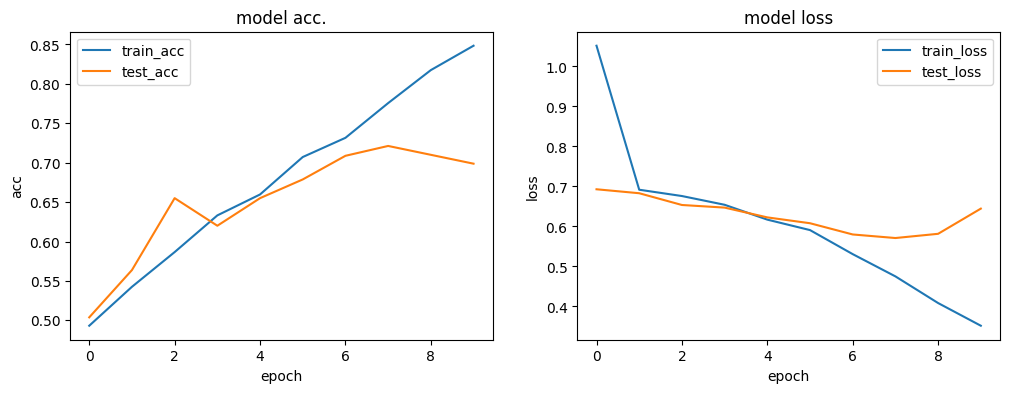

In [43]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1) ## 1행2열의 도표, 1열
plt.plot(cnn2_history.history['accuracy'])
plt.plot(cnn2_history.history['val_accuracy'])
plt.title('model acc.')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend(['train_acc','test_acc'])

plt.subplot(1, 2, 2) ## 1행2열의 도표, 2열
plt.plot(cnn2_history.history['loss'])
plt.plot(cnn2_history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss','test_loss'])

In [44]:
load_model_final = load_model('./best_cnn_final.h5')
load_model_final

<Sequential name=sequential_1, built=True>

In [45]:
final_result2 = load_model_final.predict(X_test)
final_result2[:10]

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


array([[0.3082457 ],
       [0.01703343],
       [0.25302216],
       [0.18069315],
       [0.23450482],
       [0.6005627 ],
       [0.9690654 ],
       [0.17857964],
       [0.60201   ],
       [0.44442722]], dtype=float32)

In [46]:
y_test[:10]

array([1, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [47]:
final_result3 = []
for x in final_result2:
    if x > 0.5 :
        final_result3.append(1)
    else:
        final_result3.append(0)
final_result3[:10]

[0, 0, 0, 0, 0, 1, 1, 0, 1, 0]

In [48]:
np.mean(final_result3 == y_test)

np.float64(0.69875)